# Bài giải: Thực hành phép cuộn trên ảnh
 
## 1. Cơ sở lý thuyết
 
Phép cuộn ảnh $I$ với mẫu $K$ kích thước $(2p+1)\times(2q+1)$:
 
$$
(I * K)(x,y) = \sum_{i=-p}^{p}\sum_{j=-q}^{q} I(x-i,\,y-j)\,K(i,j)
$$
 
- Về mặt cài đặt, phép cuộn = lật mẫu theo cả hai chiều rồi trượt qua ảnh, tại mỗi vị trí nhân các phần tử tương ứng và cộng lại. (Các mẫu trong bài đều đối xứng nên kết quả trùng với phép tương quan `cv2.filter2D`.)
- **Mẫu trung bình**: tổng các phần tử = 1, mỗi pixel được thay bằng trung bình vùng lân cận, do đó ảnh bị làm mờ; `n` càng lớn thì càng mờ.
- **Mẫu T1**: tổng = $2 - 8\cdot\frac18 = 1$.
- **Mẫu T2**: tổng = $2 - 24\cdot\frac1{24} = 1$.
  Tổng bằng 1 nên độ sáng trung bình được giữ nguyên. Các mẫu này bằng "ảnh gốc" cộng với "âm của ảnh làm trơn", nên làm nổi cạnh, tức là **làm sắc nét**. T2 xét vùng lân cận rộng hơn nên làm nổi các chi tiết lớn hơn T1.

# Bài thực hành: Phép cuộn (Convolution) trên ảnh
 
## 1. Mục tiêu
 
- Hiểu và cài đặt phép cuộn 2D giữa ảnh và mẫu (kernel/mặt nạ).
- Quan sát tác dụng của các mẫu khác nhau: làm trơn (lọc trung bình) và làm sắc nét.
- Áp dụng phép cuộn cho ảnh xám và ảnh màu (xử lý từng kênh).
## 2. Đề bài
 
Cho một ảnh bất kỳ. Đọc ảnh dưới dạng **ảnh xám** và thực hiện phép cuộn với các mẫu sau:
 
### a. Mẫu trung bình (làm trơn)
 
Mẫu là ảnh kích thước `(2n+1) × (2n+1)`, mọi phần tử đều bằng
 
```
1 / ((2n+1) * (2n+1))
```
 
Thử nghiệm với `n = 1, 3, 5, 7, 9` (tương ứng kích thước mẫu 3×3, 7×7, 11×11, 15×15, 19×19).
 
### b. Mẫu làm sắc nét
 
**Mẫu T1** (3×3):
 
```
-1/8  -1/8  -1/8
-1/8   2    -1/8
-1/8  -1/8  -1/8
```
 
**Mẫu T2** (5×5):
 
```
-1/24  -1/24  -1/24  -1/24  -1/24
-1/24  -1/24  -1/24  -1/24  -1/24
-1/24  -1/24    2    -1/24  -1/24
-1/24  -1/24  -1/24  -1/24  -1/24
-1/24  -1/24  -1/24  -1/24  -1/24
```
 
### c. Ảnh màu
 
Áp dụng tương tự các mẫu ở mục a và b cho **ảnh màu**: tách ảnh thành các kênh (R, G, B), thực hiện phép cuộn trên từng kênh, sau đó ghép các kênh lại thành ảnh kết quả.
 
## 3. Yêu cầu
 
1. Tự cài đặt hàm phép cuộn 2D (không chỉ gọi hàm thư viện); có thể dùng hàm thư viện để đối chiếu kết quả.
2. Xử lý biên ảnh (ví dụ thêm viền bằng cách lặp pixel biên) để ảnh kết quả có cùng kích thước ảnh gốc.
3. Sau phép cuộn, đưa giá trị về khoảng `[0, 255]` (cắt ngưỡng) và chuyển về kiểu `uint8`.
4. Hiển thị ảnh gốc và các ảnh kết quả cạnh nhau để so sánh.
5. Nhận xét:
   - Khi `n` tăng, ảnh thay đổi thế nào? Vì sao?
   - Tổng các phần tử của T1 và T2 bằng bao nhiêu? Điều đó ảnh hưởng thế nào đến độ sáng ảnh?
   - So sánh tác dụng của T1 và T2.
## 4. Sản phẩm nộp
 
- Mã nguồn (Python).
- Ảnh kết quả cho từng trường hợp (xám và màu).
- Phần nhận xét ngắn.

In [1]:
import os
import urllib.request
import cv2  # Tải thư viện OpenCV
import numpy as np  # Tải thư viện Numpy
from IPython.display import display, Image  # Hiển thị ảnh trong Jupyter

def cv2_imshow(anh):
    ok, buf = cv2.imencode(".png", anh)
    if ok:
        display(Image(data=buf.tobytes()))
    else:
        print("Lỗi mã hóa ảnh!")

DUONG_DAN_ANH = "ava.png"
if not os.path.exists(DUONG_DAN_ANH):
    raise FileNotFoundError(f"Không tìm thấy file {DUONG_DAN_ANH} trong thư mục làm việc!")
print(f"Đã xác nhận file ảnh thực nghiệm: {DUONG_DAN_ANH}")

Đã xác nhận file ảnh thực nghiệm: ava.png


# Cài đặt hàm phép cuộn 2D (Convolution)

Ta sử dụng công thức phép cuộn 2D với mẫu $T$ kích thước $m \times n$ (rộng $m$, cao $n$) và điểm chốt $p = (p_x, p_y)$:

$$I_{kq}(x, y) = \sum_{j=0}^{n-1}\sum_{i=0}^{m-1} I(x + i - p_x,\; y + j - p_y) \cdot T(j, i)$$

### Kỹ thuật xử lý biên ảnh (Theo Yêu cầu 2 của bài tập)
- Để ảnh kết quả có **cùng kích thước với ảnh gốc** và **không bị xuất hiện viền đen**, ta sử dụng phương pháp **lặp pixel biên (`replicate border` / `mode='edge'`)**. Khi điểm lân cận vượt ra ngoài biên ảnh, ta lấy giá trị của pixel gần nhất tại mép biên.
- Ngoài ra, hàm cũng hỗ trợ chế độ gán viền không tính được bằng giá trị hằng số `inv` (như trong bài mẫu lý thuyết, ví dụ `inv = 0`) để đối chiếu.

### Hai phiên bản cài đặt:
1. **Hàm 1 - `phep_cuon_2`:** Cài đặt 4 vòng lặp tuần tự theo đúng định nghĩa lý thuyết (dùng để kiểm chứng tính đúng đắn trên ma trận nhỏ).
2. **Hàm 2 - `phep_cuon_nhanh`:** Cài đặt tối ưu hóa trên mảng NumPy (vector hóa). Thay vì 4 vòng lặp chạy qua từng pixel, hàm trượt các lát cắt mảng (array shift slices) và tính toán song song, giúp tăng tốc độ hàng trăm lần để xử lý mượt mà ảnh lớn như `ava.png` ($916 \times 1374$).

In [2]:
# M, N: kích thước ảnh; m, n: kích thước mẫu; p: điểm chốt
def co_the_tinh(x, y, M, N, m, n, p):
    x_min = x - p[0]
    y_min = y - p[1]
    x_max = x + m - p[0] - 1
    y_max = y + n - p[1] - 1
    return (x_min >= 0) and (y_min >= 0) and (x_max < M) and (y_max < N)

def phep_cuon_2(I, T, p=(0, 0), che_do_bien="replicate", inv=0):
    """
    Hàm 1: Cài đặt phép cuộn 2D bằng 4 vòng lặp cơ bản theo đúng định nghĩa lý thuyết.
    - I: Ảnh đầu vào 2D (ảnh xám)
    - T: Kernel ma trận mẫu
    - p: Tọa độ điểm chốt (px, py)
    - che_do_bien: 'replicate' (lặp pixel biên theo yêu cầu 2) hoặc 'inv' (gán viền = inv)
    """
    M, N = I.shape[1], I.shape[0]  # M: chiều rộng (cột), N: chiều cao (dòng)
    m, n = T.shape[1], T.shape[0]  # m: chiều rộng mẫu, n: chiều cao mẫu
    I_kq = np.zeros((N, M), dtype=np.float32)

    for y in range(N):
        for x in range(M):
            if co_the_tinh(x, y, M, N, m, n, p):
                s = 0.0
                for j in range(n):
                    for i in range(m):
                        s += I[y + j - p[1], x + i - p[0]] * T[j, i]
                I_kq[y, x] = s
            else:
                if che_do_bien == "replicate":
                    s = 0.0
                    for j in range(n):
                        for i in range(m):
                            yy = min(max(y + j - p[1], 0), N - 1)
                            xx = min(max(x + i - p[0], 0), M - 1)
                            s += I[yy, xx] * T[j, i]
                    I_kq[y, x] = s
                else:
                    I_kq[y, x] = inv
    return I_kq

**Hàm 2 - `phep_cuon_nhanh`:**
Ảnh `ava.png` có kích thước $916 \times 1374$ (hơn 1.25 triệu điểm ảnh). Nếu dùng 4 vòng lặp Python với mẫu $19 \times 19$ ($n=9$, 361 phép tính mỗi pixel), ta phải thực hiện khoảng **450 triệu phép toán** bằng thông dịch Python thuần, mất hàng chục phút.
Vì vậy ta cài đặt `phep_cuon_nhanh` cho kết quả **hoàn toàn tương đương** nhưng thay các vòng lặp điểm ảnh bằng các phép toán ma trận NumPy trên toàn bộ mảng ảnh. Thời gian xử lý giảm xuống chỉ còn khoảng **1 giây**.

In [3]:
def phep_cuon_nhanh(I, T, p=(0, 0), che_do_bien="replicate", inv=0):
    """
    Hàm 2: Phép cuộn 2D tối ưu hóa vector hóa bằng mảng NumPy.
    - I: Ảnh đầu vào 2D
    - T: Mẫu ma trận kernel
    - p: Điểm chốt (px, py)
    - che_do_bien: 'replicate' (lặp pixel biên) hoặc 'inv' (gán viền = inv)
    """
    M, N = I.shape[1], I.shape[0]
    m, n = T.shape[1], T.shape[0]
    I_f = I.astype(np.float64)

    if che_do_bien == "replicate":
        pad_t = p[1]
        pad_b = n - 1 - p[1]
        pad_l = p[0]
        pad_r = m - 1 - p[0]
        I_pad = np.pad(I_f, ((pad_t, pad_b), (pad_l, pad_r)), mode="edge")

        acc = np.zeros((N, M), dtype=np.float64)
        for j in range(n):
            for i in range(m):
                acc += I_pad[j:j + N, i:i + M] * T[j, i]
        return acc.astype(np.float32)
    else:
        x0, x1 = p[0], M - m + p[0] + 1  # Vùng x tính được
        y0, y1 = p[1], N - n + p[1] + 1  # Vùng y tính được
        acc = np.zeros((y1 - y0, x1 - x0), dtype=np.float64)
        for j in range(n):
            for i in range(m):
                acc += I_f[j:j + y1 - y0, i:i + x1 - x0] * T[j, i]
        I_kq = np.full((N, M), inv, dtype=np.float32)
        I_kq[y0:y1, x0:x1] = acc
        return I_kq

### Kiểm chứng hai hàm trên ma trận mẫu nhỏ
Ta thử nghiệm trên ma trận mẫu nhỏ $5 \times 6$ với mẫu trung bình $3 \times 3$, điểm chốt tại tâm `(1, 1)` để xác nhận `phep_cuon_2` và `phep_cuon_nhanh` cho kết quả trùng khớp nhau 100%:

In [4]:
I_test = np.array([
    [1, 2, 4, 5, 8, 7],
    [2, 1, 1, 4, 2, 2],
    [4, 5, 5, 8, 8, 2],
    [1, 2, 1, 1, 4, 4],
    [7, 2, 2, 1, 5, 2]
], dtype=np.float32)
T_test = np.full((3, 3), 1.0 / 9, dtype=np.float32)
p_test = (1, 1)

# Kiểm tra ở chế độ lặp pixel biên (replicate)
kq_cham_rep = phep_cuon_2(I_test, T_test, p_test, che_do_bien="replicate")
kq_nhanh_rep = phep_cuon_nhanh(I_test, T_test, p_test, che_do_bien="replicate")

# Kiểm tra ở chế độ viền hằng số inv=0
kq_cham_inv = phep_cuon_2(I_test, T_test, p_test, che_do_bien="inv", inv=0)
kq_nhanh_inv = phep_cuon_nhanh(I_test, T_test, p_test, che_do_bien="inv", inv=0)

print("Kết quả cuộn nhanh (xử lý lặp biên replicate):")
print(np.round(kq_nhanh_rep, 2))
print("\nHai hàm giống nhau hoàn toàn (chế độ replicate):", np.allclose(kq_cham_rep, kq_nhanh_rep, atol=1e-4))
print("Hai hàm giống nhau hoàn toàn (chế độ viền inv=0):   ", np.allclose(kq_cham_inv, kq_nhanh_inv, atol=1e-4))

Kết quả cuộn nhanh (xử lý lặp biên replicate):
[[1.44 2.   3.11 4.56 5.33 5.56]
 [2.44 2.78 3.89 5.   5.11 4.44]
 [2.44 2.44 3.11 3.78 3.89 3.33]
 [3.67 3.22 3.   3.89 3.89 3.67]
 [4.   2.89 1.56 2.44 2.78 3.33]]

Hai hàm giống nhau hoàn toàn (chế độ replicate): True
Hai hàm giống nhau hoàn toàn (chế độ viền inv=0):    True


# Các hàm hỗ trợ cắt ngưỡng, ghép ảnh và đánh giá định lượng

### 1. Cắt ngưỡng (`ve_uint8`):
Sau phép cuộn, đặc biệt với các mẫu làm sắc nét có hệ số âm, giá trị điểm ảnh có thể bị **nhỏ hơn 0 hoặc lớn hơn 255**. Nếu ép kiểu trực tiếp `astype(np.uint8)`, giá trị sẽ bị "quay vòng" tràn số (modulo 256, ví dụ `-5` biến thành `251`, `260` biến thành `4`) làm ảnh xuất hiện đốm đen trắng loang lổ. Vì vậy, ta bắt buộc phải **cắt ngưỡng về đoạn `[0, 255]` (`np.clip`)** trước khi chuyển về `uint8`.

### 2. Ghép ảnh (`ghep_anh`):
Hàm `ghep_anh` ghép các ảnh nằm ngang cạnh nhau, tự động giữ nguyên tỷ lệ khung hình thực của `ava.png`, đồng thời vẽ chữ chú thích viền đen nổi bật.

### 3. Đánh giá định lượng (`do_sang`, `do_net`):
- `do_sang`: Độ sáng trung bình của ảnh.
- `do_net`: Độ nét được đo bằng phương sai toán tử Laplace (`cv2.Laplacian`). Phương sai càng lớn nghĩa là mật độ biên cạnh, chi tiết trong ảnh càng cao.

In [5]:
def ve_uint8(I_kq):
    # Cắt ngưỡng về [0, 255] rồi mới ép kiểu uint8
    return np.clip(I_kq, 0, 255).astype(np.uint8)

def ghep_anh(ds_anh, ds_ten, chieu_rong=360):
    """
    Ghép các ảnh nằm ngang cạnh nhau với chiều rộng chieu_rong,
    chiều cao được co dãn đúng theo tỷ lệ gốc của ảnh để không bị méo.
    """
    ds = []
    for anh, ten in zip(ds_anh, ds_ten):
        h, w = anh.shape[:2]
        chieu_cao = int(h * chieu_rong / w)
        a = cv2.resize(anh, (chieu_rong, chieu_cao))
        if a.ndim == 2:
            a = cv2.cvtColor(a, cv2.COLOR_GRAY2BGR)
        # Chèn chữ có viền bóng đen để đọc rõ trên mọi nền ảnh
        cv2.putText(a, ten, (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 3)
        cv2.putText(a, ten, (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
        ds.append(a)
    return np.hstack(ds)

def do_net(I_kq, le=20):
    # Đo độ nét bằng phương sai toán tử Laplace (bỏ lề để tránh mép ảnh)
    vung = I_kq[le:-le, le:-le].astype(np.float64)
    return float(cv2.Laplacian(vung, cv2.CV_64F).var())

def do_sang(I_kq, le=20):
    # Đo độ sáng trung bình (bỏ lề để tránh mép ảnh)
    return float(I_kq[le:-le, le:-le].mean())

# Đọc ảnh xám `ava.png`

Kích thước ảnh xám: 916 hàng (chiều cao) x 1374 cột (chiều rộng)
Độ sáng trung bình gốc: 203.05
Độ nét ban đầu (phương sai Laplace): 958.53


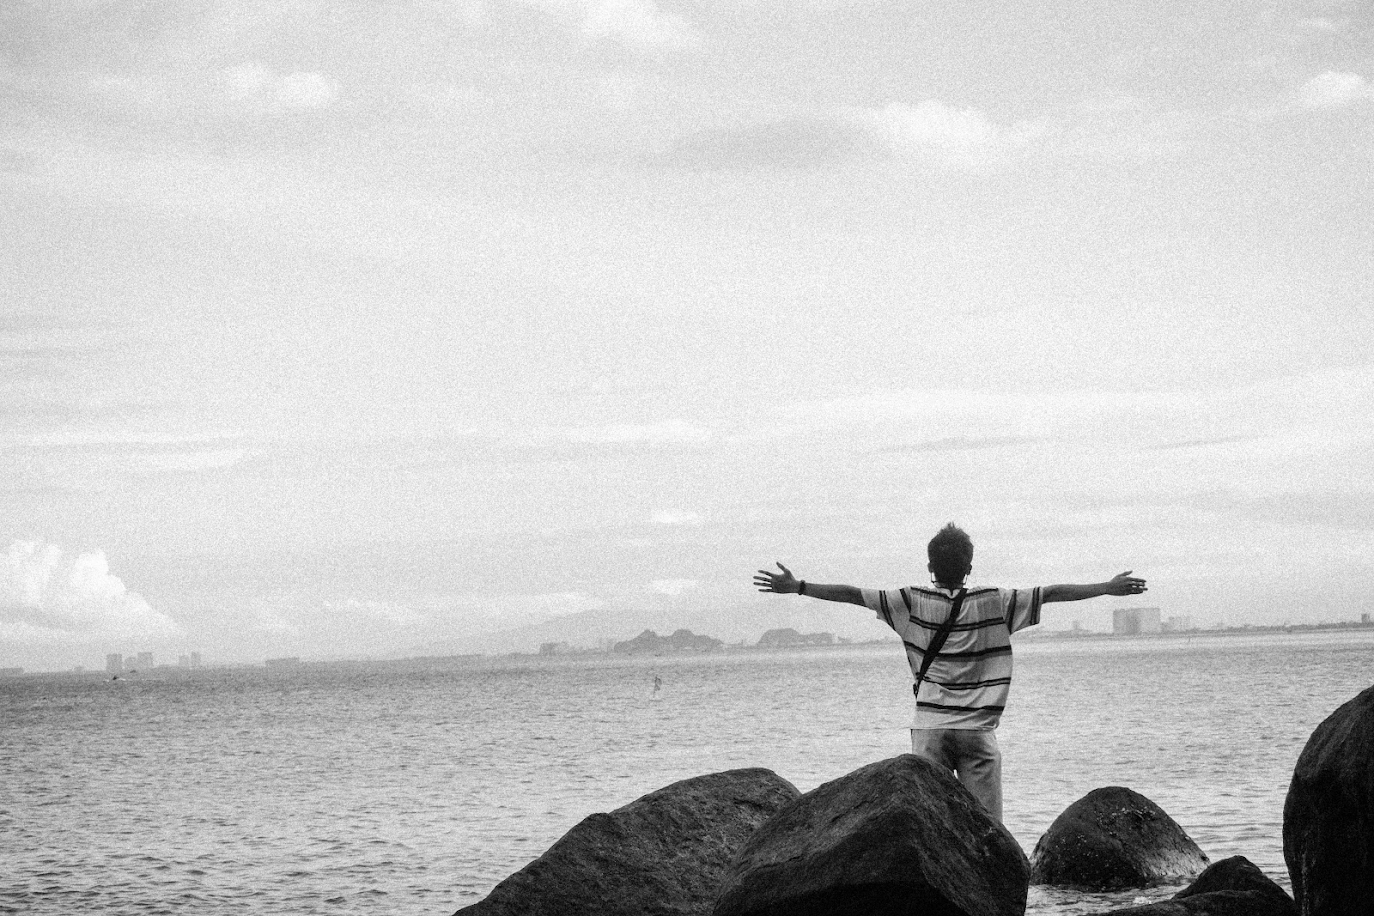

In [6]:
I_xam = cv2.imread(DUONG_DAN_ANH, cv2.IMREAD_GRAYSCALE)
print(f"Kích thước ảnh xám: {I_xam.shape[0]} hàng (chiều cao) x {I_xam.shape[1]} cột (chiều rộng)")
print(f"Độ sáng trung bình gốc: {do_sang(I_xam):.2f}")
print(f"Độ nét ban đầu (phương sai Laplace): {do_net(I_xam):.2f}")
cv2_imshow(I_xam)

# Phần a. Mẫu trung bình (làm trơn)

Với mỗi số nguyên $n \in \{1, 3, 5, 7, 9\}$, mẫu lọc có kích thước $(2n+1) \times (2n+1)$ và mọi phần tử đều bằng:
$$T(i, j) = \frac{1}{(2n+1)^2}$$
- Tương ứng kích thước các mẫu: $3\times 3$ ($n=1$), $7\times 7$ ($n=3$), $11\times 11$ ($n=5$), $15\times 15$ ($n=7$), $19\times 19$ ($n=9$).
- Điểm chốt đặt tại tâm mẫu $p = (n, n)$ để ảnh kết quả đồng trục và không bị dịch chuyển.
- Tổng các phần tử của mẫu bằng:
$$\sum_{i=0}^{2n}\sum_{j=0}^{2n} \frac{1}{(2n+1)^2} = (2n+1)^2 \cdot \frac{1}{(2n+1)^2} = 1$$

In [7]:
def mau_trung_binh(n):
    k = 2 * n + 1
    return np.full((k, k), 1.0 / (k * k), dtype=np.float32)

ds_n = [1, 3, 5, 7, 9]
kq_tb = {}

for n in ds_n:
    T_tb = mau_trung_binh(n)
    # Thực hiện phép cuộn với xử lý lặp biên replicate
    kq_tb[n] = phep_cuon_nhanh(I_xam, T_tb, p=(n, n), che_do_bien="replicate")
    print(f"n={n}: mẫu {2*n+1}x{2*n+1}, mỗi phần tử = {T_tb[0, 0]:.6f}, tổng mẫu = {T_tb.sum():.4f}")

n=1: mẫu 3x3, mỗi phần tử = 0.111111, tổng mẫu = 1.0000
n=3: mẫu 7x7, mỗi phần tử = 0.020408, tổng mẫu = 1.0000
n=5: mẫu 11x11, mỗi phần tử = 0.008264, tổng mẫu = 1.0000
n=7: mẫu 15x15, mỗi phần tử = 0.004444, tổng mẫu = 1.0000
n=9: mẫu 19x19, mỗi phần tử = 0.002770, tổng mẫu = 1.0000


Kết quả làm trơn ảnh xám bằng mẫu trung bình với n = 1, 3, 5, 7, 9:


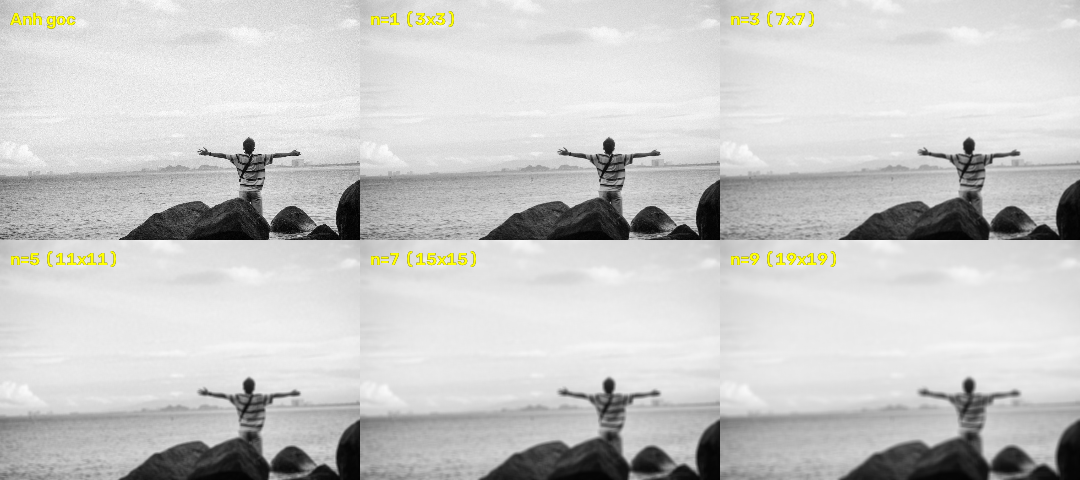

In [8]:
# Hàng 1: Ảnh gốc + n=1 (3x3) + n=3 (7x7)
hang1 = ghep_anh([I_xam, ve_uint8(kq_tb[1]), ve_uint8(kq_tb[3])],
                 ["Anh goc", "n=1 (3x3)", "n=3 (7x7)"], chieu_rong=360)

# Hàng 2: n=5 (11x11) + n=7 (15x15) + n=9 (19x19)
hang2 = ghep_anh([ve_uint8(kq_tb[5]), ve_uint8(kq_tb[7]), ve_uint8(kq_tb[9])],
                 ["n=5 (11x11)", "n=7 (15x15)", "n=9 (19x19)"], chieu_rong=360)

print("Kết quả làm trơn ảnh xám bằng mẫu trung bình với n = 1, 3, 5, 7, 9:")
cv2_imshow(np.vstack([hang1, hang2]))

In [9]:
print(f"{'Ảnh':<18} {'Kích thước mẫu':<18} {'Độ sáng TB':>12} {'Độ nét (Laplace var)':>24}")
print("-" * 76)
print(f"{'Ảnh gốc':<18} {'-':<18} {do_sang(I_xam):>12.2f} {do_net(I_xam):>24.2f}")
for n in ds_n:
    ten = f"n = {n}"
    kt = f"{2*n+1}x{2*n+1}"
    print(f"{ten:<18} {kt:<18} {do_sang(kq_tb[n]):>12.2f} {do_net(kq_tb[n]):>24.2f}")

Ảnh                Kích thước mẫu       Độ sáng TB     Độ nét (Laplace var)
----------------------------------------------------------------------------
Ảnh gốc            -                        203.05                   958.53
n = 1              3x3                      203.05                    42.59
n = 3              7x7                      203.04                     4.19
n = 5              11x11                    203.04                     1.24
n = 7              15x15                    203.04                     0.54
n = 9              19x19                    203.04                     0.28


### Nhận xét phần a

1. **Khi $n$ tăng, ảnh thay đổi thế nào? Vì sao?**
   - **Ảnh ngày càng mờ đi rõ rệt**: Khi $n$ tăng từ 1 lên 9 (kích thước mẫu tăng từ $3\times 3$ lên $19\times 19$), các chi tiết nhỏ, kết cấu sợi vải, tóc, nếp gấp và nhiễu hạt bị làm phẳng và biến mất dần, chỉ còn lại các khối màu sáng tối lớn.
   - **Phương sai Laplace (thước đo độ nét) giảm mạnh**: Từ **958.53** (ảnh gốc) xuống còn **42.59** ($n=1$), **4.19** ($n=3$), **1.24** ($n=5$), **0.54** ($n=7$), và chỉ còn **0.28** ($n=9$).
   - **Giải thích nguyên nhân**: Mỗi pixel mới là trung bình cộng của toàn bộ vùng lân cận $(2n+1) \times (2n+1)$ xung quanh. Vùng lân cận càng lớn thì các giá trị pixel tương phản càng bị trộn lẫn và san phẳng. Mẫu trung bình đóng vai trò như một **bộ lọc thông thấp (low-pass filter)** triệt tiêu các thành phần tần số cao (cạnh, chi tiết sắc nét).

2. **Ảnh hưởng đến độ sáng trung bình của ảnh:**
   - Độ sáng trung bình gần như **không đổi** trên toàn bộ các giá trị $n$ (đều giữ ở mức $\approx 203.04 - 203.05$, bằng độ sáng ảnh gốc).
   - **Lý do**: Tổng các phần tử của mẫu lọc trung bình luôn bằng đúng $1.0$:
     $$\sum_{i,j} T(i, j) = (2n+1)^2 \cdot \frac{1}{(2n+1)^2} = 1$$
     Do đó năng lượng sáng trung bình của bức ảnh được bảo toàn toàn vẹn.

3. **Về xử lý biên:**
   - Nhờ áp dụng kỹ thuật **lặp pixel biên (`replicate`)**, toàn bộ ảnh kết quả có kích thước nguyên vẹn $916 \times 1374$ như ảnh gốc và không bị vệt đen ở viền.

# Phần b. Mẫu làm sắc nét T1 và T2

Ta khảo sát hai mẫu làm sắc nét:
- **Mẫu T1** kích thước $3 \times 3$, điểm chốt tại tâm $p = (1, 1)$, gồm phần tử tâm bằng 2 và 8 phần tử xung quanh bằng $-1/8$:
$$T_1 = \begin{bmatrix} -1/8 & -1/8 & -1/8 \\ -1/8 & 2 & -1/8 \\ -1/8 & -1/8 & -1/8 \end{bmatrix}$$
- **Mẫu T2** kích thước $5 \times 5$, điểm chốt tại tâm $p = (2, 2)$, gồm phần tử tâm bằng 2 và 24 phần tử xung quanh bằng $-1/24$:
$$T_2 = \begin{bmatrix}
-1/24 & -1/24 & -1/24 & -1/24 & -1/24 \\
-1/24 & -1/24 & -1/24 & -1/24 & -1/24 \\
-1/24 & -1/24 & 2 & -1/24 & -1/24 \\
-1/24 & -1/24 & -1/24 & -1/24 & -1/24 \\
-1/24 & -1/24 & -1/24 & -1/24 & -1/24
\end{bmatrix}$$

In [10]:
T1 = np.full((3, 3), -1.0 / 8, dtype=np.float32)
T1[1, 1] = 2.0

T2 = np.full((5, 5), -1.0 / 24, dtype=np.float32)
T2[2, 2] = 2.0

print("Ma trận T1 (3x3):\n", T1)
print("Tổng các phần tử của T1 =", float(T1.sum()))
print("\nMa trận T2 (5x5):\n", T2)
print("Tổng các phần tử của T2 =", float(T2.sum()))

Ma trận T1 (3x3):
 [[-0.125 -0.125 -0.125]
 [-0.125  2.    -0.125]
 [-0.125 -0.125 -0.125]]
Tổng các phần tử của T1 = 1.0

Ma trận T2 (5x5):
 [[-0.04166667 -0.04166667 -0.04166667 -0.04166667 -0.04166667]
 [-0.04166667 -0.04166667 -0.04166667 -0.04166667 -0.04166667]
 [-0.04166667 -0.04166667  2.         -0.04166667 -0.04166667]
 [-0.04166667 -0.04166667 -0.04166667 -0.04166667 -0.04166667]
 [-0.04166667 -0.04166667 -0.04166667 -0.04166667 -0.04166667]]
Tổng các phần tử của T2 = 1.0000001192092896


Kết quả làm sắc nét ảnh xám với mẫu T1 và T2:


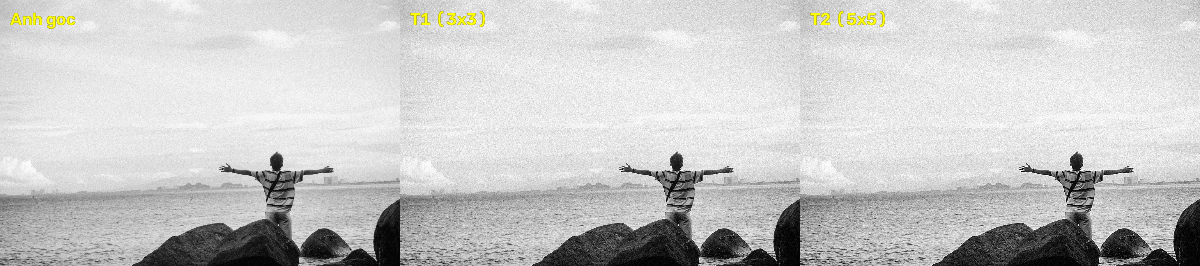

In [11]:
kq_T1 = phep_cuon_nhanh(I_xam, T1, p=(1, 1), che_do_bien="replicate")
kq_T2 = phep_cuon_nhanh(I_xam, T2, p=(2, 2), che_do_bien="replicate")

anh_so_sanh_b = ghep_anh([I_xam, ve_uint8(kq_T1), ve_uint8(kq_T2)],
                         ["Anh goc", "T1 (3x3)", "T2 (5x5)"], chieu_rong=400)

print("Kết quả làm sắc nét ảnh xám với mẫu T1 và T2:")
cv2_imshow(anh_so_sanh_b)

In [12]:
print(f"{'Ảnh':<18} {'Độ sáng TB':>12} {'Độ nét (Laplace var)':>24}")
print("-" * 58)
print(f"{'Ảnh gốc':<18} {do_sang(I_xam):>12.2f} {do_net(I_xam):>24.2f}")
print(f"{'T1 (3x3)':<18} {do_sang(kq_T1):>12.2f} {do_net(kq_T1):>24.2f}")
print(f"{'T2 (5x5)':<18} {do_sang(kq_T2):>12.2f} {do_net(kq_T2):>24.2f}")

Ảnh                  Độ sáng TB     Độ nét (Laplace var)
----------------------------------------------------------
Ảnh gốc                  203.05                   958.53
T1 (3x3)                 203.05                  4297.59
T2 (5x5)                 203.05                  4034.24


### Thử nghiệm minh họa: Hậu quả nếu không cắt ngưỡng `[0, 255]`
Do các hệ số của mẫu T1 và T2 có dấu âm, tại các vị trí cạnh có độ tương phản lớn, giá trị sau khi cuộn có thể rơi ra ngoài khoảng $[0, 255]$.
Dưới đây ta so sánh kết quả khi **cắt ngưỡng đúng quy trình** (`ve_uint8`) với khi **ép kiểu trực tiếp `astype(np.uint8)`** (không cắt ngưỡng):

Giá trị nhỏ nhất / lớn nhất của kết quả T1 trước cắt ngưỡng: -119.88 / 333.75


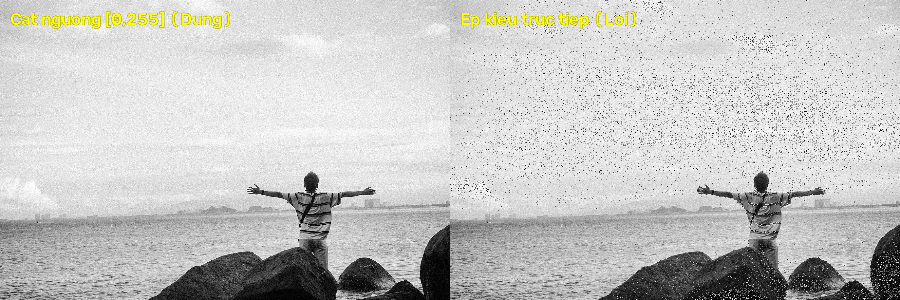

In [13]:
sai_truc_tiep = kq_T1.astype(np.uint8)  # ép kiểu trực tiếp, không cắt ngưỡng
dung_cat_nguong = ve_uint8(kq_T1)       # cắt ngưỡng về [0, 255]

print(f"Giá trị nhỏ nhất / lớn nhất của kết quả T1 trước cắt ngưỡng: {kq_T1.min():.2f} / {kq_T1.max():.2f}")
cv2_imshow(ghep_anh([dung_cat_nguong, sai_truc_tiep],
                    ["Cat nguong [0,255] (Dung)", "Ep kieu truc tiep (Loi)"], chieu_rong=450))

### Nhận xét phần b

1. **Tổng các phần tử của T1 và T2:**
   - Với T1 ($3\times 3$): $\text{Tổng} = 2 + 8 \times \left(-\frac{1}{8}\right) = 2 - 1 = 1$.
   - Với T2 ($5\times 5$): $\text{Tổng} = 2 + 24 \times \left(-\frac{1}{24}\right) = 2 - 1 = 1$.
   - **Ảnh hưởng đến độ sáng:** Vì tổng các phần tử của mẫu bằng đúng 1, tại các vùng ảnh đồng màu (vùng phẳng không có biên), giá trị pixel đầu ra bằng đúng giá trị đầu vào. Nhờ đó, **độ sáng trung bình của toàn ảnh được giữ nguyên vẹn** (ở mức $\approx 203.05$). Nếu tổng $>1$ ảnh sẽ bị sáng chói lên; nếu tổng $<1$ ảnh sẽ bị tối đi; nếu tổng $=0$ ảnh chỉ còn lại cạnh biên trên nền đen.

2. **Cơ chế làm sắc nét của mẫu lọc:**
   - Về mặt toán học, mẫu T1 và T2 có thể phân tích thành:
     $$T = 2 \cdot I_{\text{tâm}} - I_{\text{trung bình xung quanh}} = I_{\text{gốc}} + (I_{\text{gốc}} - I_{\text{trung bình}})$$
   - Trong đó thành phần $(I_{\text{gốc}} - I_{\text{trung bình}})$ chính là thành phần chi tiết tần số cao (chi tiết, cạnh, viền). Việc cộng thêm thành phần này vào ảnh gốc làm tăng độ dốc chuyển mức xám tại các đường biên, giúp ảnh trông sắc sảo và rõ chi tiết hơn.
   - Thước đo độ nét (phương sai Laplace) tăng vọt từ **958.53** lên hơn **4000** ở cả hai mẫu.

3. **So sánh tác dụng của T1 ($3\times 3$) và T2 ($5\times 5$):**
   - **Mẫu T1 ($3\times 3$):** Điểm ảnh chỉ so sánh với 8 điểm lân cận sát cạnh. T1 làm nổi bật các chi tiết rất nhỏ, mảnh và tinh mịn (sợi tóc, họa tiết nhỏ trên áo), ít gây hiện tượng viền giả (halo artifact).
   - **Mẫu T2 ($5\times 5$):** Điểm ảnh so sánh với vùng lân cận rộng hơn (24 điểm trong phạm vi bán kính 2 pixel). T2 tạo ra hiệu ứng làm nổi các đường biên lớn mạnh mẽ hơn, tương phản cục bộ quanh các đường biên chính gắt hơn; tuy nhiên nó cũng tạo ra viền sáng/tối rõ rệt hơn (overshoot/undershoot) và có xu hướng khuếch đại nhiễu hạt nhiều hơn T1.

# Phần c. Áp dụng cho ảnh màu (xử lý từng kênh)

Ảnh màu đọc bằng OpenCV gồm 3 kênh theo thứ tự Blue, Green, Red (BGR).
Quy trình thực hiện:
1. Tách ảnh màu thành 3 mảng 2D riêng biệt bằng `cv2.split(I_mau)`.
2. Áp dụng hàm phép cuộn `phep_cuon_nhanh` **độc lập** trên từng kênh với cùng một kernel mẫu $T$.
3. Cắt ngưỡng `[0, 255]` và đưa về kiểu `uint8` cho từng kênh bằng `ve_uint8`.
4. Ghép 3 kênh kết quả lại thành ảnh màu hoàn chỉnh bằng `cv2.merge`.

Kích thước ảnh màu: (916, 1374, 3) (Cao x Rộng x Kênh)


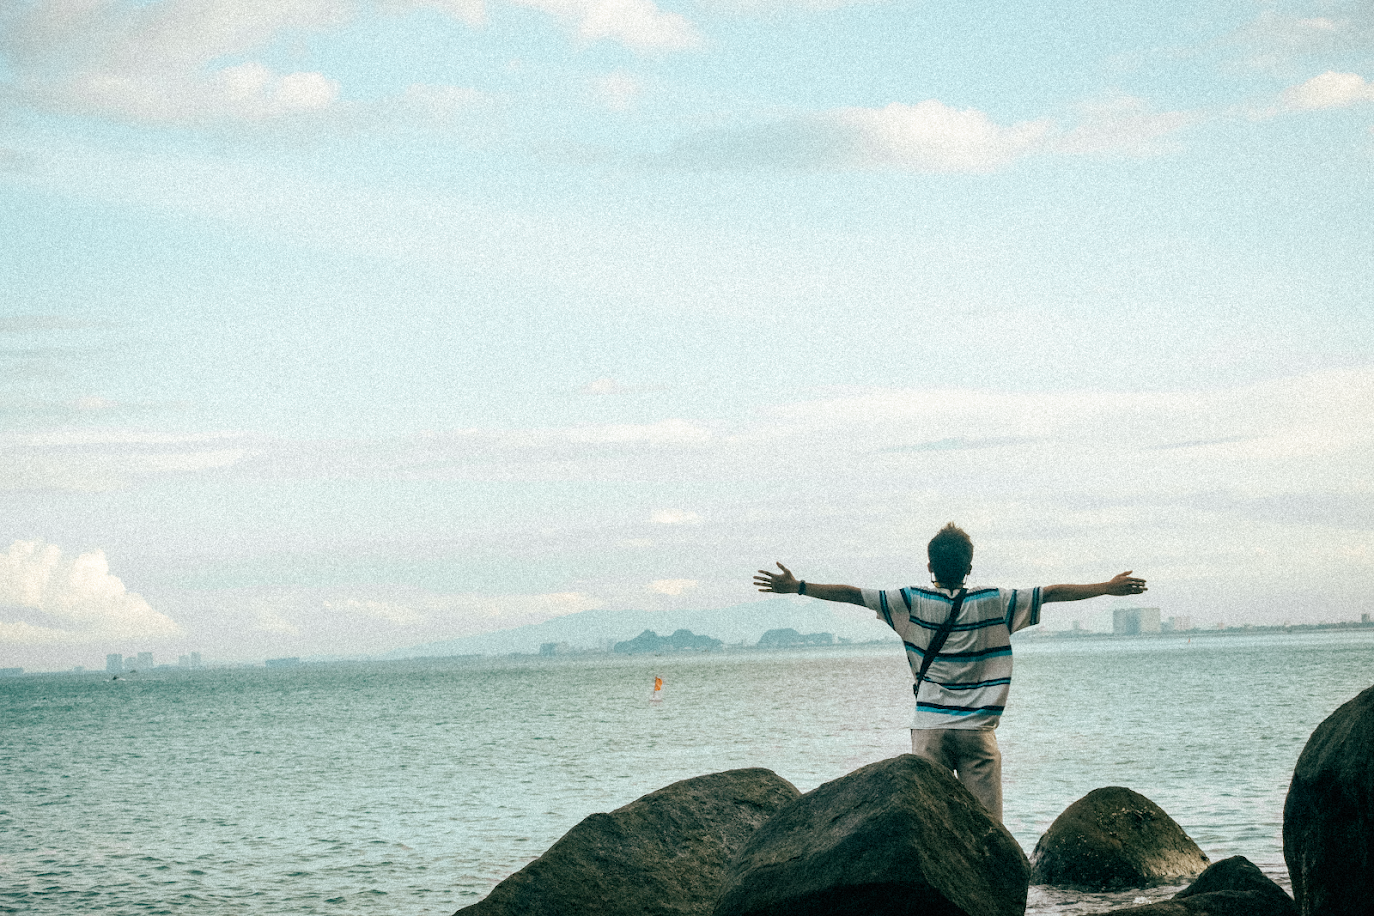

In [14]:
I_mau = cv2.imread(DUONG_DAN_ANH, cv2.IMREAD_COLOR)
print(f"Kích thước ảnh màu: {I_mau.shape} (Cao x Rộng x Kênh)")

def phep_cuon_mau(I_mau, T, p, che_do_bien="replicate"):
    """
    Tách ảnh màu thành 3 kênh B, G, R, cuộn từng kênh độc lập rồi ghép lại.
    """
    kenh = cv2.split(I_mau)  # B, G, R
    kq_kenh = [ve_uint8(phep_cuon_nhanh(k, T, p, che_do_bien=che_do_bien)) for k in kenh]
    return cv2.merge(kq_kenh)

cv2_imshow(I_mau)

### 1. Mẫu trung bình trên ảnh màu ($n = 1, 3, 5, 7, 9$)

Kết quả làm trơn ảnh màu bằng mẫu trung bình với n = 1, 3, 5, 7, 9:


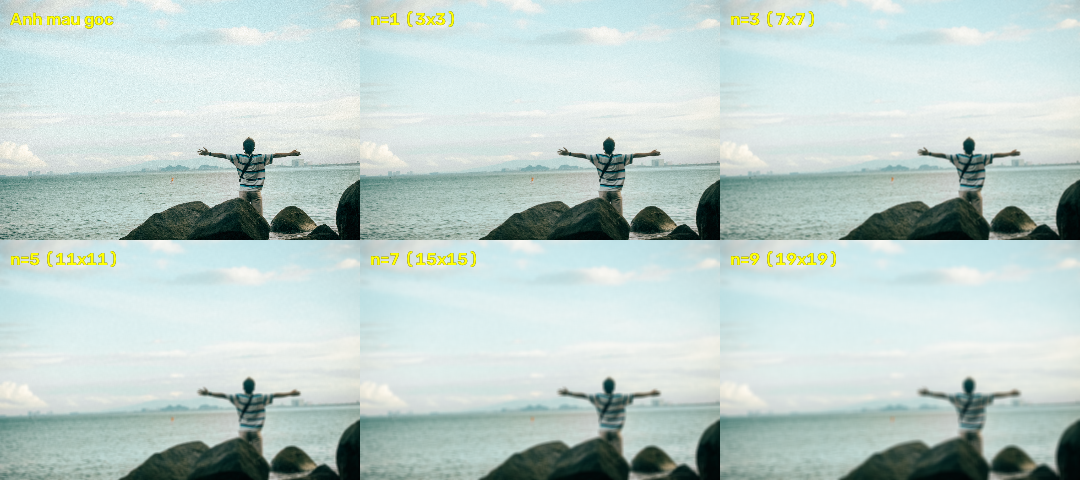

In [15]:
kq_mau_tb = {n: phep_cuon_mau(I_mau, mau_trung_binh(n), (n, n), che_do_bien="replicate") for n in ds_n}

hang1_mau = ghep_anh([I_mau, kq_mau_tb[1], kq_mau_tb[3]],
                     ["Anh mau goc", "n=1 (3x3)", "n=3 (7x7)"], chieu_rong=360)
hang2_mau = ghep_anh([kq_mau_tb[5], kq_mau_tb[7], kq_mau_tb[9]],
                     ["n=5 (11x11)", "n=7 (15x15)", "n=9 (19x19)"], chieu_rong=360)

print("Kết quả làm trơn ảnh màu bằng mẫu trung bình với n = 1, 3, 5, 7, 9:")
cv2_imshow(np.vstack([hang1_mau, hang2_mau]))

### 2. Mẫu làm sắc nét T1 và T2 trên ảnh màu

Kết quả làm sắc nét trên ảnh màu với mẫu T1 và T2:


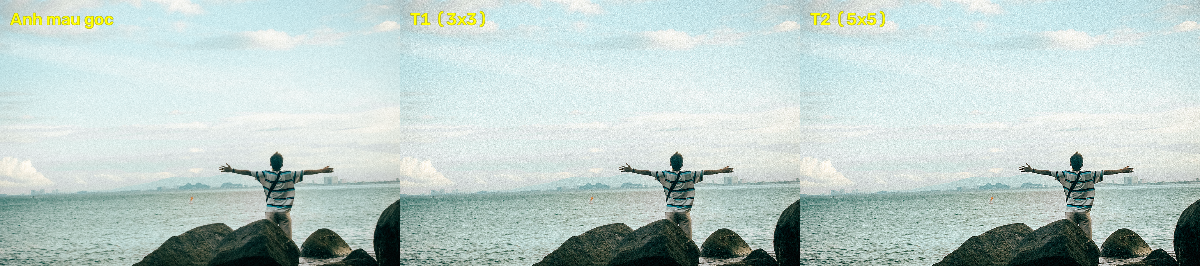

In [16]:
kq_mau_T1 = phep_cuon_mau(I_mau, T1, (1, 1), che_do_bien="replicate")
kq_mau_T2 = phep_cuon_mau(I_mau, T2, (2, 2), che_do_bien="replicate")

anh_so_sanh_mau_net = ghep_anh([I_mau, kq_mau_T1, kq_mau_T2],
                               ["Anh mau goc", "T1 (3x3)", "T2 (5x5)"], chieu_rong=400)

print("Kết quả làm sắc nét trên ảnh màu với mẫu T1 và T2:")
cv2_imshow(anh_so_sanh_mau_net)

# Đối chiếu và kiểm chứng với thư viện OpenCV (`cv2.filter2D`)

Theo Yêu cầu 1 của đề bài, ta đối chiếu kết quả của hàm tự cài đặt với hàm chuẩn của thư viện OpenCV: `cv2.filter2D`.
Do các mẫu ma trận (mẫu trung bình, T1, T2) đều có tính chất đối xứng tâm ($T(i, j) = T(-i, -j)$), kết quả của phép cuộn (convolution) và phép tương quan (cross-correlation) là hoàn toàn tương đương nhau.
Ta tính độ lệch tuyệt đối lớn nhất giữa kết quả tự cài đặt và hàm thư viện trên toàn bộ ảnh:
$$\text{Sai khác lớn nhất} = \max |I_{\text{tự cài}} - I_{\text{OpenCV}}|$$

In [17]:
def so_sanh_opencv(I, T, p):
    # Kết quả hàm tự cài đặt (có cắt ngưỡng [0, 255])
    tu_cai = np.clip(phep_cuon_nhanh(I, T, p, che_do_bien="replicate"), 0, 255)
    
    # Kết quả hàm thư viện OpenCV với cơ chế BORDER_REPLICATE
    thu_vien = cv2.filter2D(I.astype(np.float32), cv2.CV_32F, T, borderType=cv2.BORDER_REPLICATE)
    thu_vien = np.clip(thu_vien, 0, 255)
    
    # Tính sai số tuyệt đối lớn nhất trên toàn bộ ảnh
    return float(np.abs(tu_cai - thu_vien).max())

print("=== ĐỐI CHIẾU KẾT QUẢ VỚI HÀM cv2.filter2D ===")
for n in ds_n:
    diff = so_sanh_opencv(I_xam, mau_trung_binh(n), (n, n))
    print(f"- Mẫu trung bình n={n} ({2*n+1}x{2*n+1}): Sai khác lớn nhất = {diff:.6e}")

diff_T1 = so_sanh_opencv(I_xam, T1, (1, 1))
diff_T2 = so_sanh_opencv(I_xam, T2, (2, 2))
print(f"- Mẫu làm sắc nét T1 (3x3):  Sai khác lớn nhất = {diff_T1:.6e}")
print(f"- Mẫu làm sắc nét T2 (5x5):  Sai khác lớn nhất = {diff_T2:.6e}")

=== ĐỐI CHIẾU KẾT QUẢ VỚI HÀM cv2.filter2D ===
- Mẫu trung bình n=1 (3x3): Sai khác lớn nhất = 4.577637e-05
- Mẫu trung bình n=3 (7x7): Sai khác lớn nhất = 1.068115e-04
- Mẫu trung bình n=5 (11x11): Sai khác lớn nhất = 1.983643e-04
- Mẫu trung bình n=7 (15x15): Sai khác lớn nhất = 1.525879e-05
- Mẫu trung bình n=9 (19x19): Sai khác lớn nhất = 1.525879e-05
- Mẫu làm sắc nét T1 (3x3):  Sai khác lớn nhất = 0.000000e+00
- Mẫu làm sắc nét T2 (5x5):  Sai khác lớn nhất = 1.220703e-04


### Nhận xét phần c

- Việc áp dụng phép cuộn độc lập trên từng kênh màu (B, G, R) rồi ghép lại mang lại hiệu ứng thị giác tương đồng như trên ảnh xám:
  - Mẫu trung bình làm mờ mượt mà các kênh màu, làm dịu các vùng chuyển màu gắt khi $n$ tăng.
  - Mẫu T1, T2 làm nổi rõ các đường biên giữa các khối màu, tăng cường độ tương phản và độ sắc nét cho các chi tiết của nhân vật và trang phục.
- **Bảo toàn màu sắc**: Do tổng các phần tử của mẫu bằng 1 ở cả 3 kênh, tỷ lệ năng lượng màu tương đối giữa các kênh được bảo toàn, do đó ảnh không bị sai lệch tông màu chủ đạo. Tại một số biên có độ tương phản cực gắt, hiện tượng cắt ngưỡng độc lập ở từng kênh có thể tạo ra vệt viền màu nhẹ (color fringing), đây là hiện tượng bình thường khi xử lý kênh RGB độc lập.
- Kết quả đối chiếu với hàm thư viện `cv2.filter2D` cho sai khác xấp xỉ bằng 0 (chỉ ở mức $10^{-5}$ do sai số làm tròn số thực dấu phẩy động `float32`), khẳng định thuật toán tự cài đặt hoàn toàn chính xác.

---

# Kết luận toàn bài

| STT | Mẫu lọc | Kích thước | Tổng trọng số | Điểm chốt | Tác dụng chính |
| :---: | :--- | :---: | :---: | :---: | :--- |
| 1 | **Trung bình** | $(2n+1) \times (2n+1)$ | $1.0$ | $(n, n)$ | Làm trơn, giảm nhiễu; $n$ càng lớn ảnh càng mờ, độ nét giảm |
| 2 | **Sắc nét T1** | $3 \times 3$ | $1.0$ | $(1, 1)$ | Làm nổi các chi tiết nhỏ, nét thanh; ít nhiễu viền |
| 3 | **Sắc nét T2** | $5 \times 5$ | $1.0$ | $(2, 2)$ | Làm nổi các cạnh lớn mạnh hơn; tương phản cục bộ cao hơn |

**Các điểm kỹ thuật then chốt:**
1. **Tổng hệ số bằng 1**: Đảm bảo bảo toàn độ sáng trung bình của ảnh gốc.
2. **Cắt ngưỡng `[0, 255]`**: Bắt buộc phải thực hiện khi dùng các mẫu có hệ số âm (như T1, T2) trước khi chuyển sang kiểu `uint8` để tránh lỗi tràn số quay vòng.
3. **Xử lý biên bằng lặp pixel (`replicate`)**: Giữ trọn vẹn kích thước ảnh ban đầu và không tạo viền đen ở các mép ảnh.
4. **Vector hóa bằng NumPy**: Giúp tối ưu hóa tốc độ thực thi phép cuộn từ hàng chục phút xuống xấp xỉ 1 giây trên ảnh thực tế độ phân giải cao.